<a href="https://colab.research.google.com/github/Harukokoko/Haruka-Nakagawa/blob/main/%E2%98%85uncomtrade_DLdata.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [43]:
# メモ、uncomtradeの2023年  all to all export data (downloaded by free)の格納場所
# C:\Users\haruk\AppData\Local\Temp\MicrosoftEdgeDownloads\f2db363a-9fa7-4d1f-81f2-4c0aba57e591

ダウンロードデータバージョン。
UNComtradeのAPIはいつrejectされるかわからないので、UNComtradeのサイトから無料ダウンロードしたデータ（輸出国・相手国：指定なし、HS：HS28、2023年）を使用


cord source: https://github.com/uncomtrade/comtradeapicall

## 0. 準備

In [44]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from typing import List, Dict, Tuple, Callable
import scipy as sp
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import io
import os

## 1-1. データダウンロード

## 1-1-1. 今回はExcelでダウンロードしたデータをとりあえず使う

In [45]:
# 使わない！！！
#file_path = "C:/Users/haruk/iCloudDrive/Documents/Research/99_Sotsuron/download.csv"
#if os.path.exists(file_path):
    #print("ファイルが見つかりました")
#else:
    #print("ファイルが見つかりません")


In [46]:
# 使わない！！！
#file_path = r"C:/Users/haruk/iCloudDrive/Documents/Research/99_Sotsuron/download.csv"
#df = pd.read_csv(file_path)
#print(df.head())

## 1-1-2 データダウンロード別方法で

In [47]:
# 違う方法でダウンロード
import networkx as nx
from google.colab import files
uploaded = files.upload()

Saving ex_2023_all_all_HS28_dlbyfree.xlsx to ex_2023_all_all_HS28_dlbyfree (1).xlsx


## 1-2. データフレーム化

In [48]:
# アップロードされたファイル名を取得
file_name = list(uploaded.keys())[0]

# ExcelファイルをPandasデータフレームに変換
df = pd.read_excel(io.BytesIO(uploaded[file_name]))

# データフレームを確認
df.head()

,typeCode,freqCode,refPeriodId,refYear,refMonth,period,reporterCode,reporterISO,reporterDesc,flowCode,...,netWgt,isNetWgtEstimated,grossWgt,isGrossWgtEstimated,cifvalue,fobvalue,primaryValue,legacyEstimationFlag,isReported,isAggregate
0,C,A,20230101,2023,52,2023,8,ALB,Albania,X,...,0.0,False,0,False,NaN,600.027,600.027,0,False,True
1,C,A,20230101,2023,52,2023,8,ALB,Albania,X,...,0.0,False,0,False,NaN,905957.447,905957.447,0,False,True
2,C,A,20230101,2023,52,2023,8,ALB,Albania,X,...,0.0,False,0,False,NaN,53.515,53.515,0,False,True
3,C,A,20230101,2023,52,2023,8,ALB,Albania,X,...,0.0,False,0,False,NaN,28956.347,28956.347,0,False,True
4,C,A,20230101,2023,52,2023,8,ALB,Albania,X,...,0.0,False,0,False,NaN,3746.140,3746.140,0,False,True


##1-2　データ解説

**Selection Criteria**
- typeCode(str) : Product type. Goods (C) or Services (S)
- freqCode(str) : The time interval at which observations occur. Annual (A) or Monthly (M)
- clCode(str) : Indicates the product classification used and which version (HS, SITC)
- period(str) : Combination of year and month (for monthly), year for (annual)
- reporterCode(str) : The country or geographic area to which the measured statistical phenomenon relates
- cmdCode(str) : Product code in conjunction with classification code
- flowCode(str) : Trade flow or sub-flow (exports, re-exports, imports, re-imports, etc.)
- partnerCode(str) : The primary partner country or geographic area for the respective trade flow
- partner2Code(str) : A secondary partner country or geographic area for the respective trade flow
- customsCode(str) : Customs or statistical procedure
- motCode(str) : The mode of transport used when goods enter or leave the economic territory of a country

### 抽出指定
商品データ、年次、HSコード、2023年、報告国は指定なし、品目は HSCode28_Inorganic chemicals; organic or inorganic compounds of precious metals, of rare-earth metals, of radioactive elements or of isotopes （無機化学品及び貴金属、希土類金属、放射性元素又は同位元素の無機又は有機の化合物）、輸出データ、貿易相手国は指定なし、積送国の指定なし、税関コード指定なし、貿易手段指定なし

### 詳説
**typeCode='C':**
これは、データのタイプを示します。'C' はコモディティ（商品）データを意味します。

**freqCode='A':**
データの頻度を指定します。'M'は「月次データ」を意味します。年次データであれば 'A' になります。

**clCode='HS':**
使用される商品分類コードを指定します。'HS'は「Harmonized System（国際統一商品分類）」を指します。この場合、HSコードに基づいた商品データを取得します。

**period='2023':**
データの期間（年）を指定します。ここでは2023年のデータを要求しています。

**reporterCode='156':**
報告国（データを提供している国）のコードです。'156' は中国を意味します。

**cmdCode='21':**
商品コードを指定します。'21' はHSコードで特定の商品カテゴリを表しています。この場合、HSコードの21に該当する商品（レアアース）についてのデータを取得しています。

**flowCode='X':**
貿易フローを指定します。'X'は「輸出」を意味し、輸出データを取得することを指します。'M'であれば輸入データを指定します。

**partnerCode=None:**
貿易相手国のコードです。None と指定されているので、特定の相手国に限定せず、全パートナー国を対象にします。

**partner2Code=None:**
追加の貿易相手国コード（例: 貿易ハブを経由する場合）ですが、Noneに設定されています。

**customsCode=None:**
税関コードを指定します。None なので特定の税関コードを使用しません。

**motCode=None:**
貿易手段（モード・オブ・トランスポート）のコードです。Noneなので、特定の輸送手段に限定しません。

**maxRecords=500:**
取得するデータの最大レコード数です。ここでは、最大500件のデータを取得するように指定されています。

**format_output='JSON':**
データの出力形式を指定します。ここでは、'JSON'形式でデータを取得するようにしています。他にCSV形式などが利用可能な場合もあります。

**aggregateBy=None:**
データの集計方法を指定しますが、Noneなので集計しません。必要に応じて集計軸を指定することもできます。

**breakdownMode='classic':**
データの細分化のモードを指定します。ここでは「classic」を選択しています。これにより、標準的な分解モードでデータが提供されます。

**countOnly=None:**
データの件数だけを取得するかどうかを指定します。Noneなので、件数ではなく実際のデータを取得します。

**includeDesc=True:**
商品コードや国コードの詳細説明をデータに含めるかどうかを指定します。True なので、コードに対応する説明（国名や商品名など）がデータに含まれます。

**カラム説明**

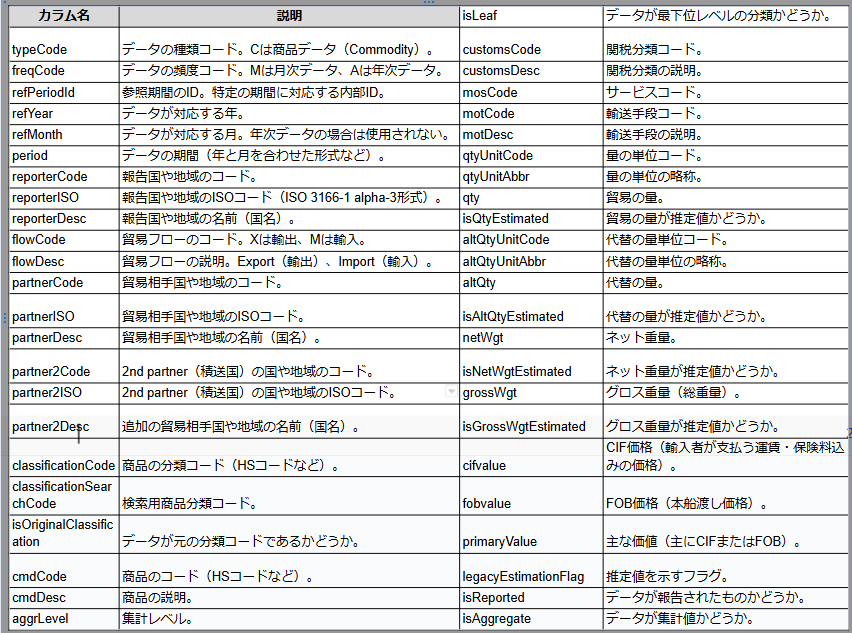

**2nd partner countryについて**
https://uncomtrade.org/docs/second-partner-country/

## 1-2. データ概観

In [49]:
# 列名
print(df.columns)

Index(['typeCode', 'freqCode', 'refPeriodId', 'refYear', 'refMonth', 'period',
       'reporterCode', 'reporterISO', 'reporterDesc', 'flowCode', 'flowDesc',
       'partnerCode', 'partnerISO', 'partnerDesc', 'partner2Code',
       'partner2ISO', 'partner2Desc', 'classificationCode',
       'classificationSearchCode', 'isOriginalClassification', 'cmdCode',
       'cmdDesc', 'aggrLevel', 'isLeaf', 'customsCode', 'customsDesc',
       'mosCode', 'motCode', 'motDesc', 'qtyUnitCode', 'qtyUnitAbbr', 'qty',
       'isQtyEstimated', 'altQtyUnitCode', 'altQtyUnitAbbr', 'altQty',
       'isAltQtyEstimated', 'netWgt', 'isNetWgtEstimated', 'grossWgt',
       'isGrossWgtEstimated', 'cifvalue', 'fobvalue', 'primaryValue',
       'legacyEstimationFlag', 'isReported', 'isAggregate'],
      dtype='object')


In [50]:
#　データ数
print(df.shape)

(11454, 47)


In [51]:
# 国数
len(df['reporterDesc'].unique())

139

In [52]:
print(df['reporterDesc'].unique())

['Albania' 'Angola' 'Antigua and Barbuda' 'Austria' 'Bahrain'
 'Bolivia (Plurinational State of)' 'Armenia' 'Botswana'
 'Brunei Darussalam' 'Argentina' 'Belgium' 'Myanmar' 'Belize' 'Bulgaria'
 'Azerbaijan' 'Brazil' 'Australia' 'Bosnia Herzegovina' 'Andorra'
 'Barbados' 'Bahamas' 'Cambodia' 'Dominican Rep.' 'Costa Rica' 'Colombia'
 'Chile' 'Canada' 'Sri Lanka' 'China' 'Cyprus' 'Croatia' 'Benin' 'Denmark'
 'Czechia' 'Cabo Verde' 'Dominica' 'Central African Rep.' 'Ecuador'
 'Finland' 'Georgia' 'France' 'Estonia' 'Fiji' 'El Salvador' 'Djibouti'
 'Gabon' 'Ethiopia' 'China, Hong Kong SAR' 'Ghana' 'Guyana' 'Guatemala'
 'Germany' 'Greece' 'Grenada' 'Honduras' 'Indonesia' 'Kuwait'
 "Côte d'Ivoire" 'Lebanon' 'Iceland' 'Jordan' 'Kenya' 'Kyrgyzstan'
 'Malawi' 'Kazakhstan' 'Italy' 'Maldives' 'Hungary' 'Japan' 'Luxembourg'
 'Malta' 'Ireland' 'Mauritius' 'Latvia' 'Mexico' 'Israel' 'Lithuania'
 'Madagascar' 'Malaysia' 'Jamaica' 'Liberia' 'Mauritania' 'Lesotho' 'Peru'
 'Saudi Arabia' 'Other Asia, nes' 

In [53]:
print(df['partnerDesc'].unique())

['Hungary' 'Italy' 'Norway' 'Thailand' 'USA' 'China' 'Belgium' 'Croatia'
 'Saudi Arabia' 'Greece' 'Serbia' 'North Macedonia' 'Slovakia' 'Bulgaria'
 'Poland' 'Montenegro' 'World' 'United Kingdom' 'United Arab Emirates'
 'Spain' 'Senegal' 'Qatar' 'Panama' 'Portugal' 'Mauritania' 'Namibia'
 'Indonesia' 'Equatorial Guinea' 'Cuba' 'Czechia' 'Dem. Rep. of the Congo'
 'Congo' 'South Africa' 'Zimbabwe' 'Montserrat' 'Sint Maarten' 'Grenada'
 'Kuwait' 'United Rep. of Tanzania' 'Israel' 'Peru' 'Kenya'
 "Lao People's Dem. Rep." 'Mexico' 'Afghanistan' 'Cambodia' 'Nepal'
 'Niger' 'Nigeria' 'Papua New Guinea' 'Cameroon' 'Maldives' 'Togo'
 'France' 'Algeria' 'Angola' 'Brunei Darussalam' 'Syria' 'Uruguay'
 'Eritrea' 'Timor-Leste' 'Morocco' 'San Marino' 'Greenland' 'Ecuador'
 "Côte d'Ivoire" 'Lebanon' 'Libya' 'Malawi' 'Gabon' 'Ethiopia' 'Pakistan'
 'Luxembourg' 'Belarus' 'Mongolia' 'New Zealand' 'Guyana' 'Haiti'
 'Special Categories' 'Iraq' 'Oman' 'Latvia' 'Türkiye' 'Uganda' 'Albania'
 'Azerbaijan' 'Sie

今回のデータは11454件、139か国が含まれているが、どのように選んだのか不明なので要改善ではある

## 1-3 欠損値・外れ値処理

In [54]:
df.isnull().sum()

,0
typeCode,0
freqCode,0
refPeriodId,0
refYear,0
refMonth,0
period,0
reporterCode,0
reporterISO,0
reporterDesc,0
flowCode,0


**欠損値が50％以上ある列を削除**

In [55]:
# 欠損値の割合を計算
threshold = 0.5  # 50%以上が欠損している列を削除
df = df.loc[:, df.isna().mean() < threshold]

In [56]:
# # FOB値(fobvalue)列の統計量を計算
# max_value = df['fobvalue'].max()
# min_value = df['fobvalue'].min()
# median_value = df['fobvalue'].median()

# # 統計量を表示
# print(f"Maximum FOB Value: {max_value}")
# print(f"Minimum FOB Value: {min_value}")
# print(f"Median FOB Value: {median_value}")

# # FOB値(fobvalue)列の分布を表示
# plt.figure(figsize=(10, 6))
# plt.hist(df['fobvalue'], bins=30, edgecolor='black', alpha=0.7)
# plt.title('Distribution of FOB Values')
# plt.xlabel('FOB Value')
# plt.ylabel('Frequency')
# plt.grid(axis='y', alpha=0.75)

# # 最大値、最小値、中央値をプロット
# plt.axvline(max_value, color='red', linestyle='--', linewidth=1.5, label=f'Max: {max_value}')
# plt.axvline(min_value, color='blue', linestyle='--', linewidth=1.5, label=f'Min: {min_value}')
# plt.axvline(median_value, color='green', linestyle='--', linewidth=1.5, label=f'Median: {median_value}')

# # 凡例を表示
# plt.legend()
# plt.show()


**要チェック：FOB値って単位何でExcelに載ってるんだ**

**reportedDescがWorldの行を削除する**

In [57]:
df = df[df['reporterDesc'] != 'world']
df = df[df['partnerDesc'] != 'world']
# 結果を確認
print(f"Number of rows after filtering: {len(df)}")

Number of rows after filtering: 11454


そのうえでもう一度FOB値の分布確認

In [58]:
# # FOB値(fobvalue)列の統計量を計算
# max_value = df['fobvalue'].max()
# min_value = df['fobvalue'].min()
# median_value = df['fobvalue'].median()

# # 最大値、最小値、中央値を表示（対数変換なし）
# print(f"Maximum FOB Value (no log): {max_value}")
# print(f"Minimum FOB Value (no log): {min_value}")
# print(f"Median FOB Value (no log): {median_value}")

# # FOB値(fobvalue)列の分布を表示（対数スケール）
# plt.figure(figsize=(10, 6))
# plt.hist(df['fobvalue'], bins=30, edgecolor='black', alpha=0.7, log=True)
# plt.title('Distribution of FOB Values (Log Scale)')
# plt.xlabel('FOB Value')
# plt.ylabel('Frequency (Log Scale)')
# plt.grid(axis='y', alpha=0.75)

# # 最大値、最小値、中央値をプロット（対数スケールに変換してプロット）
# plt.axvline(max_value, color='red', linestyle='--', linewidth=1.5, label=f'Max: {max_value}')
# plt.axvline(min_value, color='blue', linestyle='--', linewidth=1.5, label=f'Min: {min_value}')
# plt.axvline(median_value, color='green', linestyle='--', linewidth=1.5, label=f'Median: {median_value}')

# # 凡例を表示
# plt.legend()
# plt.show()

まだ外れ値があるので何が外れているのか確認する

In [59]:
# # FOB値が最大である行を抽出
# max_row = df[df['fobvalue'] == max_value]

# # 最大値を持つ行のreporterDescとpartnerDescを表示
# reporter = max_row['reporterDesc'].values[0]
# partner = max_row['partnerDesc'].values[0]

# print(f"Reporter with max FOB value: {reporter}")
# print(f"Partner with max FOB value: {partner}")

In [60]:
# # FOB値の第一四分位範囲を計算
# q1 = df['fobvalue'].quantile(0.25)
# q3 = df['fobvalue'].quantile(0.75)

# # 第一四分位範囲のデータを抽出
# iqr_data = df[(df['fobvalue'] >= q1) & (df['fobvalue'] <= q3)]

# # 抽出したデータの分布を表示（対数スケール）
# plt.figure(figsize=(10, 6))
# plt.hist(iqr_data['fobvalue'], bins=30, edgecolor='black', alpha=0.7, log=True)
# plt.title('Distribution of FOB Values (First Quartile Range, Log Scale)')
# plt.xlabel('FOB Value')
# plt.ylabel('Frequency (Log Scale)')
# plt.grid(axis='y', alpha=0.75)

# # 第一四分位範囲の境界線をプロット
# plt.axvline(q1, color='orange', linestyle='--', linewidth=1.5, label=f'Q1: {q1}')
# plt.axvline(q3, color='purple', linestyle='--', linewidth=1.5, label=f'Q3: {q3}')

# # 凡例を表示
# plt.legend()
# plt.show()

・小さい値にデータ数が集まっているので、不用意に削除すると鉱物輸出量が少ないだけで主要な国同士とのやり取りである行を削除する恐れがある

・今はデータ数減らしたくない

↓

一旦そのまま使う

# 2. ネットワーク可視化

## 2-1. データをネットワーク構造に落とし込む

### ①UNcomtrade analysis.ipynb を参考にしたもの

In [61]:
# --------------------------------------------------
# Extract nodes (as dataframe)

#nodes = df['reporterDesc']

# --------------------------------------------------
# Extract edges (as dataframe)

#edges = df['fobvalue']

# --------------------------------------------------

In [62]:
# #def create_graph(edges: pd.DataFrame) -> nx.DiGraph:
#     """
#     Create a single directed graph from the edges dataframe without layers.
#     """
#     # 列名をマッピング
#     source_col = "reporterDesc"  # ノード（出発側）の列名
#     target_col = "partnerDesc"  # ノード（到着側）の列名
#     weight_col = "fobvalue"     # 重み（貿易額）の列名

#     # 単一グラフを作成
#     graph = nx.from_pandas_edgelist(
#         edges,
#         source=source_col,
#         target=target_col,
#         edge_attr=weight_col,
#         create_using=nx.DiGraph
#     )
#     return graph

In [63]:
# Extract various graph properties (as dict)

#gprops_df = pd.read_csv(target + "/gprops.csv", on_bad_lines='skip')
#gprops_df.columns = gprops_df.columns.str.replace(" ", "")
#gprops_df.columns = gprops_df.columns.str.replace("#", "")

# make a dict object out of the gprops dataframe
#gprops = gprops_df.set_index("prop_name").to_dict()["value"]

# extract the layers keys (as a dict)
#layer_keys = {}
#for item in gprops["layer_key"] \
    #.replace(" ", "").replace("\n", "") \
    #.replace("{", "").replace("}", "") \
    #.split("',"):

    #keyvalue = item.split(":'")
    #layer_keys[int(keyvalue[0])] = keyvalue[1]

#gprops["layer_key"] = layer_keys

#del layer_keys, gprops_df

# --------------------------------------------------
# replace numeric index with textual names

# replace country indexes in edges
#edges["source"] = edges["source"].map(nodes["name"])
#edges["target"] = edges["target"].map(nodes["name"])

# replace commodity indexes in edges
#edges["layer"] = edges["layer"].map(gprops["layer_key"])

# set country name as node index
#nodes = nodes.set_index("name")

### ②ネットワーク本参照

## **▼データ全体のネットワーク化**

In [64]:
# 必要な列のみ抽出（必要に応じて列名を調整）
df = df[["reporterDesc", "partnerDesc", "fobvalue"]]

# FOB値が0以下の場合は除外
df = df[df["fobvalue"] > 0]

# 重複を統一するため、すべてのノード名を小文字に変換
df["reporterDesc"] = df["reporterDesc"].str.lower()
df["partnerDesc"] = df["partnerDesc"].str.lower()

# NetworkXのグラフ作成
G = nx.DiGraph()  # 有向グラフ

# ノードとエッジを追加
for _, row in df.iterrows():
    reporter = row["reporterDesc"]
    partner = row["partnerDesc"]
    weight = row["fobvalue"]

    # ノード追加（重複ノードは自動的に統一）
    G.add_node(reporter)
    G.add_node(partner)

    # エッジ追加（FOB値が0以上の場合のみ）
    if weight > 0:
        G.add_edge(reporter, partner, weight=weight)

# グラフの情報を表示
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")

Number of nodes: 240
Number of edges: 7757


In [65]:
# # グラフの描画
# plt.figure(figsize=(10, 10))
# pos = nx.spring_layout(G, seed=42)  # レイアウトを設定
# nx.draw(
#     G, pos, with_labels=True, node_size=700, node_color="lightblue", font_weight="bold"
# )
# plt.title("Trade Network")
# plt.axis("off")
# plt.show()

## **▼中国を基点としたピラミッド型**

In [66]:
# # 基点ノード
# base_node = 'china'

# # 各ノードのchinaからの距離を計算
# if base_node in G:
#     distances = nx.single_source_shortest_path_length(G, base_node)
# else:
#     raise ValueError(f"'{base_node}' not found in the graph nodes.")

# # 距離に基づいてレイヤーを作成
# layers = {}
# for node, distance in distances.items():
#     if distance not in layers:
#         layers[distance] = []
#     layers[distance].append(node)

# # カスタムレイアウトの計算
# pos = {}
# layer_y = 1.0  # 最初のレイヤーの高さ（y座標）
# for distance in sorted(layers.keys()):
#     layer_nodes = layers[distance]
#     layer_x = 0.5  # x座標の開始点
#     spacing = 1.0 / len(layer_nodes) if len(layer_nodes) > 0 else 1.0  # レイヤー内のノード間の間隔
#     for i, node in enumerate(layer_nodes):
#         pos[node] = (layer_x + i * spacing, layer_y)
#     layer_y -= 0.2  # レイヤーを下げる（y座標）

# # グラフの描画
# # グラフの描画（横幅を広げ、ラベルの文字サイズを調整）
# plt.figure(figsize=(15, 8))  # 横幅を広げる
# nx.draw(
#     G,
#     pos,
#     with_labels=True,
#     node_size=500,
#     node_color="lightblue",
#     font_weight="bold",
#     font_size=8  # ラベルの文字サイズを小さくする
# )
# plt.title("Pyramid Network Layout Based on Distance from 'china'", fontsize=14)
# plt.axis('off')
# plt.show()

二段にしか分かれていないから、おそらく中国を始点としたとき距離３以上の経路がないんだと思う。念のため確認。

In [67]:
# # 基点ノード(china)からの距離を計算
# distances = nx.single_source_shortest_path_length(G, "china")

# # 距離が3以上のノードが存在するか確認
# nodes_distance_3_or_more = {node: dist for node, dist in distances.items() if dist >= 3}

# # 結果を表示
# if nodes_distance_3_or_more:
#     print("Nodes with distance 3 or more from 'china':")
#     for node, distance in nodes_distance_3_or_more.items():
#         print(f"Node: {node}, Distance: {distance}")
# else:
#     print("No nodes with distance 3 or more from 'china'.")

次は終点をアメリカに限定して経路を描画したいけど、計算に時間がかかりすぎるので、中国→アメリカ経路のうち計算時間が現実的なものは距離いくつまで行けるのか計算してみる。
10、5、4とやってみたが4が現実的。

In [68]:
# # 中国からアメリカまで行くすべてのパスを列挙（最大距離を4に制限）
# all_paths = list(nx.all_simple_paths(G, source="china", target="usa", cutoff=4))

# # 最も長いパス（ノード数が最大のパス）を取得
# longest_path = max(all_paths, key=len)

# # 最大パスのエッジ数を計算
# max_path_length = len(longest_path) - 1  # ノード数から1を引いてエッジ数を計算

# # 結果を表示
# print(f"Longest path from 'china' to 'usa' (with max distance 10): {longest_path}")
# print(f"Number of edges in the longest path: {max_path_length}")

## **▼始点：中国→終点：アメリカ（距離４以下の経路）：subgraph**

In [69]:
# 基点と終点を設定
source_node = "china"
target_node = "usa"

# 距離4以下の経路を抽出
paths_within_distance = list(nx.all_simple_paths(G, source=source_node, target=target_node, cutoff=4))

# 距離4以下の経路に含まれるすべてのノードを抽出
nodes_within_paths = set(node for path in paths_within_distance for node in path)

# サブグラフを作成（抽出したノードのみ含む）
subgraph = G.subgraph(nodes_within_paths)

# カスタムレイアウトの計算（レイヤー構造にする）
pos = {}
layer_y = 1.0  # 最初のレイヤーの高さ（y座標）
layers = {}
for path in paths_within_distance:
    for distance, node in enumerate(path):
        if distance not in layers:
            layers[distance] = []
        if node not in layers[distance]:
            layers[distance].append(node)

for distance, nodes in sorted(layers.items()):
    layer_x = 0.5  # x座標の開始点
    spacing = 1.0 / len(nodes) if len(nodes) > 0 else 1.0  # レイヤー内のノード間隔
    for i, node in enumerate(nodes):
        pos[node] = (layer_x + i * spacing, layer_y)
    layer_y -= 0.2  # レイヤーを下げる

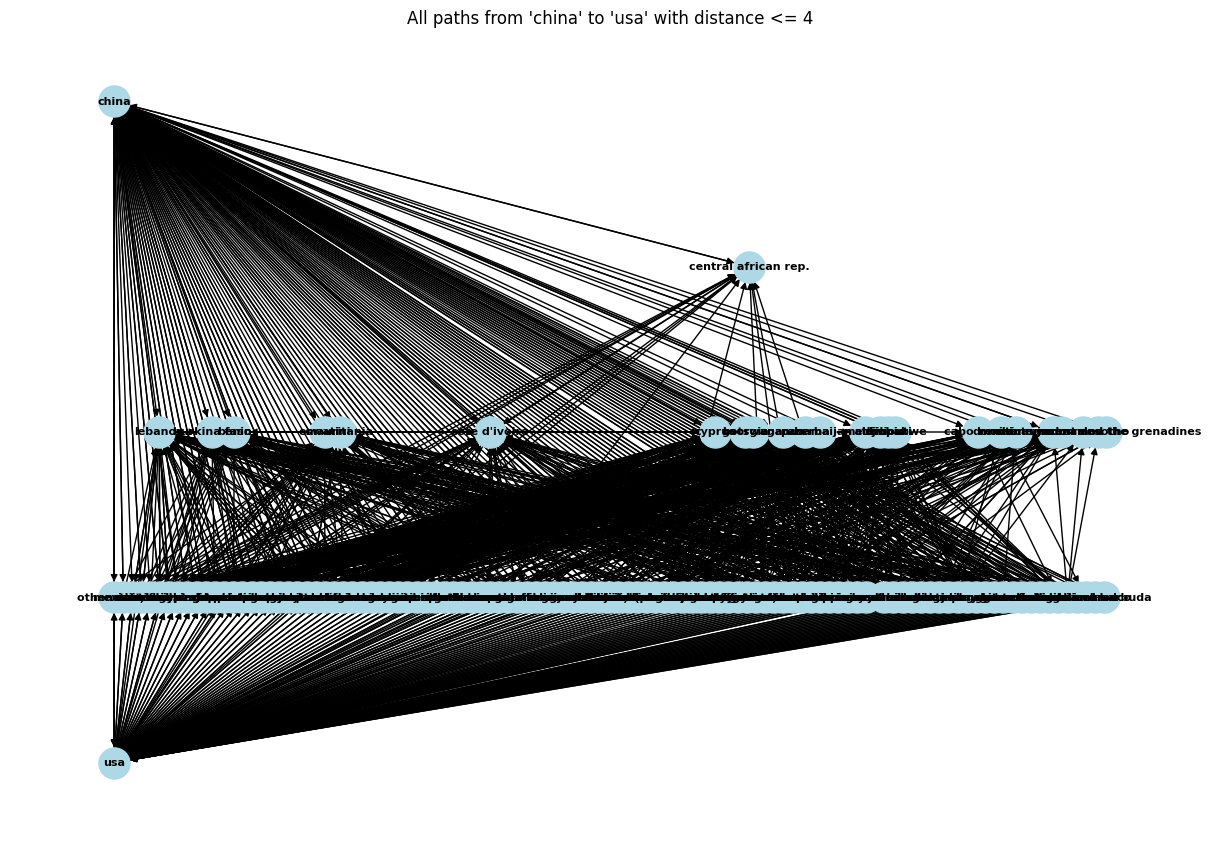

In [70]:
# グラフの描画
plt.figure(figsize=(12, 8))
nx.draw(
    subgraph,
    pos,
    with_labels=True,
    node_size=500,
    node_color="lightblue",
    font_weight="bold",
    font_size=8
)
plt.title(f"All paths from '{source_node}' to '{target_node}' with distance <= 4")
plt.axis('off')
plt.show()

In [71]:
# 中国からアメリカまでの距離4の経路を抽出
paths_with_distance_4 = [
    path for path in nx.all_simple_paths(G, source="china", target="usa", cutoff=4)
    if len(path) - 1 == 4  # 距離 = ノード数 - 1
]

# 結果を表示
print(f"Paths from 'china' to 'usa' with exact distance 4:")
for path in paths_with_distance_4:
    print(path)

Streaming output truncated to the last 5000 lines.
['china', 'greece', 'lithuania', 'belgium', 'usa']
['china', 'greece', 'lithuania', 'croatia', 'usa']
['china', 'greece', 'lithuania', 'israel', 'usa']
['china', 'greece', 'lithuania', 'south africa', 'usa']
['china', 'greece', 'lithuania', 'kyrgyzstan', 'usa']
['china', 'greece', 'lithuania', 'australia', 'usa']
['china', 'greece', 'lithuania', 'serbia', 'usa']
['china', 'greece', 'lithuania', 'philippines', 'usa']
['china', 'greece', 'lithuania', 'qatar', 'usa']
['china', 'greece', 'lithuania', 'czechia', 'usa']
['china', 'greece', 'lithuania', 'brazil', 'usa']
['china', 'greece', 'lithuania', 'rep. of moldova', 'usa']
['china', 'greece', 'lithuania', 'saudi arabia', 'usa']
['china', 'greece', 'lithuania', 'malta', 'usa']
['china', 'greece', 'lithuania', 'finland', 'usa']
['china', 'greece', 'lithuania', 'denmark', 'usa']
['china', 'greece', 'lithuania', 'nigeria', 'usa']
['china', 'greece', 'lithuania', 'north macedonia', 'usa']
['c

「中国からアメリカまでの距離4以下の経路」はめっちゃある。
たぶんグラフ上のレイヤーが4つにわかれた経路がcentral african repを通るものしかないのは、同じ描画上同じレイヤーの国同士で貿易しているから。

In [72]:
# 中国からアメリカまで行くすべてのパスを列挙（最大距離を4に制限）
all_paths = list(nx.all_simple_paths(subgraph, source="china", target="usa", cutoff=4))

# 最も長いパス（ノード数が最大のパス）を取得
longest_path = max(all_paths, key=len)

# 最大パスのエッジ数を計算
max_path_length = len(longest_path) - 1  # ノード数から1を引いてエッジ数を計算

# 結果を表示
print(f"Longest path from 'china' to 'usa' (with max distance 10): {longest_path}")
print(f"Number of edges in the longest path: {max_path_length}")

Longest path from 'china' to 'usa' (with max distance 10): ['china', 'morocco', 'india', 'mexico', 'usa']
Number of edges in the longest path: 4


# 2.流入量計算＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊

## Networkxで計算

**閉路を削除する：subgraph→dag**


すべてのサイクルを除去してしまうと、china-usaのループがすべて削除されてしまうので、usa→chinaの向きのエッジを削除してからループを削除する。

In [73]:
def convert_to_dag_with_last_edge_removal_safe(subgraph, source="china", target="usa"):
    """
    サイクルを効率的に削除してDAGに変換する。
    サイクルを閉じる最後のエッジを慎重に削除。
    """
    dag = subgraph.copy()  # サブグラフのコピーを作成

    # 1. 始点（china）と終点（usa）の間の逆向きエッジを削除
    if dag.has_edge(target, source):
        dag.remove_edge(target, source)

    # 2. サイクルを検出して削除
    while True:
        try:
            # 最初のサイクルを取得
            cycle = next(nx.simple_cycles(dag))
            # サイクルを閉じる最後のエッジを削除（慎重に行う）
            last_edge = (cycle[-1], cycle[0])
            # 削除しても `china` → `usa` のパスが残る場合のみ削除
            temp_dag = dag.copy()
            temp_dag.remove_edge(*last_edge)
            if nx.has_path(temp_dag, source, target):  # パスが残る場合
                dag.remove_edge(*last_edge)
        except StopIteration:
            # サイクルがなくなったら終了
            break

    # 3. DAGになったか確認
    if nx.is_directed_acyclic_graph(dag):
        print("The graph has been successfully converted to a DAG.")
    else:
        raise ValueError("The graph still contains cycles.")

    return dag

# 実行
dag = convert_to_dag_with_last_edge_removal_safe(subgraph, source="china", target="usa")

The graph has been successfully converted to a DAG.


**データクリーニングした（欠損値・外れ値削除、始点中国で終点アメリカに設定、閉路削除）DAG（Directed Acyclic Graph：有向非巡回グラフ）をcsv保存しておく：dag→df_cleaned**

In [74]:
# dagのエッジリストを取得してデータフレーム化しておく
df_cleaned = nx.to_pandas_edgelist(dag)

In [75]:
# # 保存先ファイルパスを指定
# file_path = r"C:/Users/haruk/iCloudDrive/Documents/Research/99_Sotsuron/sotsuron/cleaned_subgraph_edges.csv"

# # ディレクトリが存在するか確認し、存在しなければ作成
# os.makedirs(os.path.dirname(file_path), exist_ok=True)

# # データフレームを指定したパスに保存
# df_cleaned.to_csv(file_path, index=False)
# print(f"Cleaned subgraph edges have been saved at: {file_path}")

In [76]:
# 保存されたデータフレームの先頭を確認
df_cleaned.head()

,source,target,weight
0,albania,hungary,3.068991e+04
1,albania,italy,1.126369e+07
2,albania,norway,5.351500e+01
3,albania,thailand,2.895635e+04
4,albania,usa,3.789876e+03


In [77]:
print("ノードの数：", nx.number_of_nodes(G))
print("ノードの数：", nx.number_of_nodes(subgraph))
print("データの数 サイクル除去前：", df.shape[0])
print("データの数 サイクル除去後：", df_cleaned.shape[0])

ノードの数： 240
ノードの数： 135
データの数 サイクル除去前： 11454
データの数 サイクル除去後： 2969


サイクル除去するとデータが減りすぎる。

*   df：全データのデータフレーム
*   G：dfを基にreporter = row["reporterDesc"]、partner = row["partnerDesc"]、weight = row["fobvalue"]で作ったネットワーク
*   subgraph：始点china、終点usaとしたGの部分ネットワーク
*   dag：subgraphからサイクル除去（china→usaに影響しないエッジのみ削除）したもの
*   df_cleaned：dagのエッジリストをデータフレーム化したもの
*   subgraph_cleaned：subgraphからサイクル除去したもの（dag）

**今後はここから計算すればOK＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊**

In [78]:
# # 保存されたエッジリスト(csvaファイル)を読み込む
# # file_path = r"C:/Users/haruk/iCloudDrive/Documents/Research/99_Sotsuron/sotsuron/cleaned_subgraph_edges.csv"
# # df_cleaned = pd.read_csv(file_path)

# # エッジリストから有向グラフを構築
# subgraph_cleaned = nx.from_pandas_edgelist(
#     df_cleaned,
#     source='source',  # データフレームのエッジ始点列
#     target='target',  # データフレームのエッジ終点列
#     edge_attr='weight',  # 重みの列（FOB値）
#     create_using=nx.DiGraph()  # 有向グラフ
# )

In [80]:
if nx.has_path(subgraph_cleaned, source="china", target="usa"):
    print("Path exists from 'china' to 'usa'.")
else:
    print("No path exists from 'china' to 'usa'.")

Path exists from 'china' to 'usa'.


In [79]:
# 中国からアメリカまで行くすべてのパスを列挙（最大距離を4に制限）
all_paths = list(nx.all_simple_paths(subgraph_cleaned, source="china", target="usa", cutoff=4))

# 最も長いパス（ノード数が最大のパス）を取得
longest_path = max(all_paths, key=len)

# 最大パスのエッジ数を計算
max_path_length = len(longest_path) - 1  # ノード数から1を引いてエッジ数を計算

# 結果を表示
print(f"Longest path from 'china' to 'usa' (with max distance 10): {longest_path}")
print(f"Number of edges in the longest path: {max_path_length}")

Longest path from 'china' to 'usa' (with max distance 10): ['china', 'philippines', 'chile', 'kuwait', 'usa']
Number of edges in the longest path: 4


In [82]:
def calculate_flow_with_stop_on_target(G, source, target, weight='weight'):
    """
    始点から終点までの流入量を計算し、終点に到達したら計算を終了する関数。
    また、終点から始点へのエッジを削除する。

    Parameters:
        G (nx.DiGraph): 重み付き有向グラフ
        source (str): 始点ノード
        target (str): 終点ノード
        weight (str): 重み属性の名前

    Returns:
        float: 終点への最終流入量
    """
    # 終点から始点へのエッジを削除
    if G.has_edge(target, source):
        G = G.copy()  # オリジナルを変更しないためにコピー
        G.remove_edge(target, source)

    # 初期化: 各ノードの流入量を0に設定
    flow = {node: 0 for node in G.nodes}
    flow[source] = 1  # 始点の流入量を1に設定

    visited = set()  # 訪問済みノードを記録

    def dfs(node):
        if node == target:
            return  # 終点に到達したら終了

        visited.add(node)
        out_edges = G.out_edges(node, data=True)
        total_weight = sum(edge_data[weight] for _, _, edge_data in out_edges)

        if total_weight == 0:  # 出力がない場合
            return

        for _, neighbor, edge_data in out_edges:
            proportion = edge_data[weight] / total_weight
            if neighbor not in visited:
                flow[neighbor] += flow[node] * proportion
                dfs(neighbor)  # 再帰的に隣接ノードを処理

    # DFSを開始
    dfs(source)

    return flow.get(target, 0)

# アメリカへの最終流入量を計算
usa_flow = calculate_flow_with_stop_on_target(subgraph, source="china", target="usa", weight="weight")

# 結果を表示
print(f"The calculated flow into 'usa' from 'china' is: {usa_flow}")

The calculated flow into 'usa' from 'china' is: 0.07770097266694523


In [88]:
# アメリカへの最終流入量を計算：いろいろやってみる
usa_flow1 = calculate_flow_with_stop_on_target(subgraph, source="china", target="usa", weight="weight")
usa_flow2 = calculate_flow_with_stop_on_target(subgraph_cleaned, source="china", target="usa", weight="weight")

# 結果を表示
print(f"The calculated flow into 'usa' from 'china' is: {usa_flow1}")
print(f"The calculated flow into 'usa' from 'china' is: {usa_flow2}")


The calculated flow into 'usa' from 'china' is: 0.07770097266694523
The calculated flow into 'usa' from 'china' is: 0.34437922471210825


そのうち直接輸出はどのくらいの割合なのか

In [89]:
# 直接輸出割合を計算（元のサブグラフ）
if subgraph.has_edge(source_node, target_node):
    direct_weight = subgraph[source_node][target_node]["weight"]
    total_source_weight = sum(edge_data["weight"] for _, _, edge_data in subgraph.out_edges(source_node, data=True))
    direct_export_ratio1 = direct_weight / total_source_weight
else:
    direct_export_ratio1 = 0  # 直接輸出がない場合

# 直接輸出割合を計算（クリーニング後のサブグラフ）
if subgraph_cleaned.has_edge(source_node, target_node):
    direct_weight = subgraph_cleaned[source_node][target_node]["weight"]
    total_source_weight = sum(edge_data["weight"] for _, _, edge_data in subgraph_cleaned.out_edges(source_node, data=True))
    direct_export_ratio2 = direct_weight / total_source_weight
else:
    direct_export_ratio2 = 0  # 直接輸出がない場合

# 直接輸出割合を表示
print(f"The direct export ratio from '{source_node}' to '{target_node}' in original subgraph is: {direct_export_ratio1}")
print(f"The direct export ratio from '{source_node}' to '{target_node}' in cleaned subgraph is: {direct_export_ratio2}")


The direct export ratio from 'china' to 'usa' in original subgraph is: 0.07761142272774761
The direct export ratio from 'china' to 'usa' in cleaned subgraph is: 0.31634112841275625


In [90]:
# 一次経由国、二次経由国、三次経由国を取得する関数
def get_transit_countries(G, source, target):
    """
    一次経由国、二次経由国、三次経由国を抽出する関数

    Parameters:
        G (nx.DiGraph): 有向グラフ
        source (str): 始点ノード（例: "china"）
        target (str): 終点ノード（例: "usa"）

    Returns:
        dict: 各経由国リストを含む辞書
    """
    # ターゲット（アメリカ）への経路のみ抽出
    paths_to_target = [
        path for path in nx.all_simple_paths(G, source=source, target=target, cutoff=4)
    ]

    # 経由国の分類
    transit_countries = {1: set(), 2: set(), 3: set()}
    for path in paths_to_target:
        if len(path) >= 3:
            transit_countries[1].add(path[1])  # 一次経由国
        if len(path) >= 4:
            transit_countries[2].add(path[2])  # 二次経由国
        if len(path) >= 5:
            transit_countries[3].add(path[3])  # 三次経由国

    # 結果を辞書として返す
    return {k: list(v) for k, v in transit_countries.items()}

# 始点と終点を設定
source_node = "china"
target_node = "usa"

# 経由国を取得
transit_countries = get_transit_countries(subgraph, source_node, target_node)

# 結果を表示
print("Transit countries:")
print(f"1st level transit countries: {transit_countries[1]}")
print(f"2nd level transit countries: {transit_countries[2]}")
print(f"3rd level transit countries: {transit_countries[3]}")


Transit countries:
1st level transit countries: ['rep. of moldova', 'malaysia', 'antigua and barbuda', 'ghana', 'new zealand', 'uzbekistan', 'denmark', 'ukraine', 'dominican rep.', 'liberia', 'singapore', 'barbados', 'united kingdom', 'sweden', 'japan', 'tunisia', 'colombia', 'kazakhstan', 'malawi', 'ecuador', 'bosnia herzegovina', 'guyana', 'madagascar', 'oman', 'qatar', 'central african rep.', 'ethiopia', 'benin', 'lithuania', 'guatemala', 'paraguay', 'nicaragua', 'luxembourg', 'other asia, nes', 'uruguay', 'kyrgyzstan', 'senegal', 'albania', 'mauritania', 'pakistan', 'zimbabwe', 'honduras', 'uganda', 'jordan', 'south africa', 'gabon', 'jamaica', 'norway', 'dominica', 'saudi arabia', 'djibouti', 'netherlands', 'botswana', 'canada', 'egypt', 'united arab emirates', 'philippines', 'indonesia', 'belgium', 'cyprus', 'switzerland', 'greece', 'angola', 'kuwait', 'bahrain', 'fiji', 'united rep. of tanzania', 'north macedonia', 'cabo verde', 'sri lanka', 'slovenia', "côte d'ivoire", 'mozambi

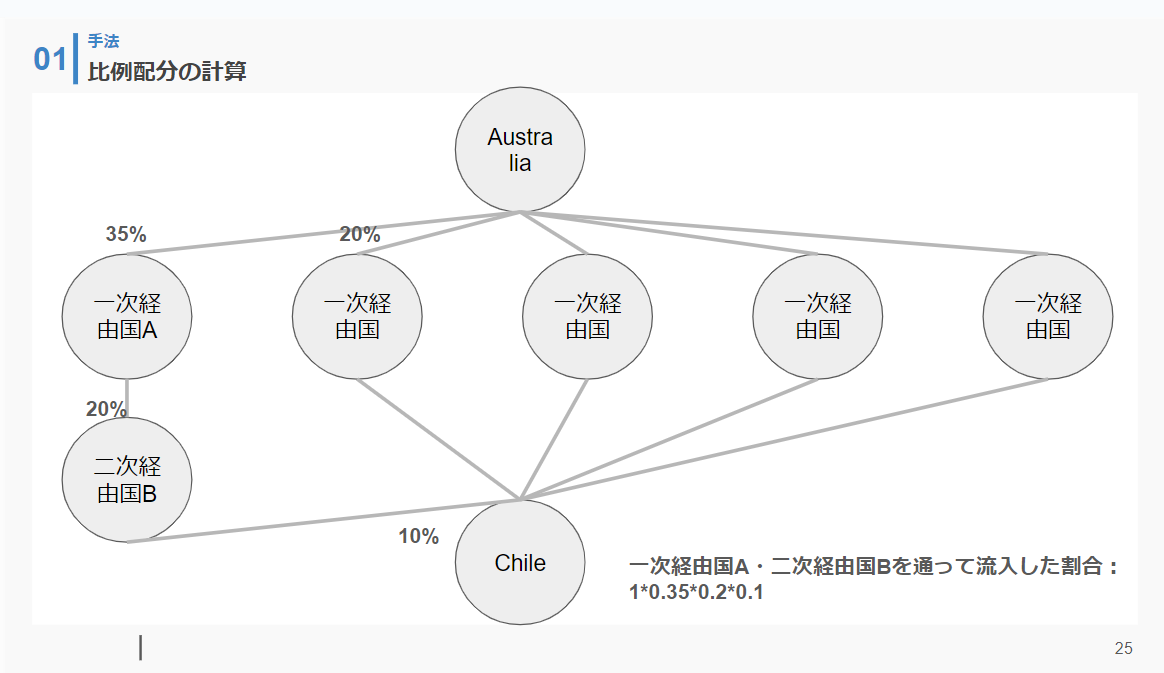